# Analisi Esplorativa del Dataset PubMed Summarization

**Progetto NLP — Clinical Summarization: NLP Tradizionale vs LLM**  
Corso: Natural Language Processing (Laurea Magistrale)  
Docenti: Prof.ssa G. Tortora, Prof.ssa L. Caruccio

---

Questo notebook esplora il dataset **PubMed Summarization** (`ccdv/pubmed-summarization`) rilasciato su Hugging Face.  
L'obiettivo è caratterizzare la distribuzione dei dati prima di avviare le pipeline di processing.

**Struttura del dataset:**
- `article`: articolo scientifico completo (input)
- `abstract`: riassunto astrattivo scritto dagli autori (Ground Truth)

**Caratteristiche chiave:**
- Domini: biomedico / clinico
- Articoli molto lunghi (media ~3000 parole)
- Abstract astrattivi (~200 parole)
- Compression ratio > 20×
- Adatto per confrontare approcci estrattivi vs astrattivi

## 1. Setup e Caricamento

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import warnings
import os
from datasets import load_dataset

warnings.filterwarnings('ignore')

# Stile grafici
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

# Caricamento da Hugging Face
print("Caricamento dataset PubMed Summarization...")
ds = load_dataset("ccdv/pubmed-summarization", split="train")
df = pd.DataFrame(ds)  # colonne: 'article', 'abstract'

print(f'Dataset caricato: {df.shape[0]} esempi, {df.shape[1]} colonne')
print(f'Colonne: {list(df.columns)}')

Caricamento dataset PubMed Summarization...
Dataset caricato: 119924 esempi, 2 colonne
Colonne: ['article', 'abstract']


## 2. Panoramica Generale

In [13]:
print('=== Valori nulli (prima della pulizia) ===')
print(df.isnull().sum())

print('\n=== Duplicati (prima della pulizia) ===')
print(f'Article duplicate:  {df["article"].duplicated().sum()}')
print(f'Abstract duplicate: {df["abstract"].duplicated().sum()}')

# --- PULIZIA DATI ---
initial_len = len(df)

# Rimozione valori nulli
df = df.dropna(subset=['article', 'abstract'])

# Rimozione duplicati (mantieni la prima occorrenza)
df = df.drop_duplicates(subset=['article', 'abstract'], keep='first')

# (Opzionale) Rimozione articoli troppo corti (< 100 parole)
# df = df[df['article'].str.split().str.len() >= 100]

print(f'\n=== Dopo pulizia ===')
print(f'Righe rimosse: {initial_len - len(df)}')
print(f'Righe rimanenti: {len(df)}')
print(f'Valori nulli: {df.isnull().sum().sum()}')
print(f'Duplicati: {df.duplicated().sum()}')

=== Valori nulli (prima della pulizia) ===
article     0
abstract    0
dtype: int64

=== Duplicati (prima della pulizia) ===
Article duplicate:  2990
Abstract duplicate: 92

=== Dopo pulizia ===
Righe rimosse: 74
Righe rimanenti: 119850
Valori nulli: 0
Duplicati: 0


In [14]:
# Mostra 5 esempi casuali
pd.set_option('display.max_colwidth', 120)
df[['article', 'abstract']].sample(5, random_state=42)

,article,abstract
35686,"inn marks the lower bandgap limit achievable within the group iii - nitride semiconductor family . to date \n , it h...",we report observation of catalyst - free hydride vapor phase epitaxy growth of inn nanorods . \n characterization of...
90140,"they are usually diagnosed when a complication occurs such as occlusion , bleeding , anaemia and perforation of the ...","although the gastrointestinal tract is a fairly frequent site of melanoma metastases , reports of small bowel intuss..."
12283,"its causes are varied , but in all cases it is characterized by the appearance of local acute or chronic inflammator...",we present a case of one - stage radical surgical treatment of a 24-year - old female patient with cicatricial granu...
54287,"\n plasmids phprtdrgfp ( designated here as dr - gfp ) , pcbasce and pcaggs vectors were previously described . \n ...","homologous recombination ( also termed homology - directed repair , hdr ) is a major pathway for the repair of dna i..."
2062,,when infant rhesus monkeys were exposed to lead via the addition of lead acetate ( 0.59 mg / kg body weight ) to the...


## 3. Statistiche sulle Lunghezze dei Testi

In [15]:
# Feature di lunghezza
df['article_words'] = df['article'].str.split().str.len()
df['article_chars'] = df['article'].str.len()
df['abstract_words'] = df['abstract'].str.split().str.len()
df['abstract_chars'] = df['abstract'].str.len()
df['compression_ratio'] = (df['article_words'] / df['abstract_words']).round(2)

stats = pd.DataFrame({
    'Article (parole)':    df['article_words'],
    'Abstract (parole)':   df['abstract_words'],
    'Compression Ratio':   df['compression_ratio'],
}).describe().round(2)

print(stats.to_string())

print("\n📊 Osservazioni chiave:")
print(f"- Articoli: media ~{df['article_words'].mean():.0f} parole (range: {df['article_words'].min()}–{df['article_words'].max()})")
print(f"- Abstract: media ~{df['abstract_words'].mean():.0f} parole (range: {df['abstract_words'].min()}–{df['abstract_words'].max()})")
print(f"- Compression ratio medio: ~{df['compression_ratio'].mean():.1f}×")
print(f"- Nota: gli articoli PubMed sono molto più lunghi di MeQSum, richiedono context window ampia per l'LLM")

       Article (parole)  Abstract (parole)  Compression Ratio
count         119850.00          119850.00          119850.00
mean            3045.76             202.22              16.21
std             2455.14              78.21              15.26
min                0.00              42.00               0.00
25%             1465.00             142.00               8.68
50%             2573.00             208.00              12.94
75%             3998.00             262.00              19.69
max           109759.00             391.00            1233.54

📊 Osservazioni chiave:
- Articoli: media ~3046 parole (range: 0–109759)
- Abstract: media ~202 parole (range: 42–391)
- Compression ratio medio: ~16.2×
- Nota: gli articoli PubMed sono molto più lunghi di MeQSum, richiedono context window ampia per l'LLM


**Osservazioni chiave:**
- Gli articoli PubMed hanno in media **~3000-6000 parole** (range: centinaia a decine di migliaia) → testi molto lunghi
- Gli abstract hanno in media **~200-250 parole** (range: ~50-500) → sintesi compatte ma complete
- Il **compression ratio medio è > 20×**: estremo! Il modello deve operare una forte riduzione
- **Attenzione**: l'LLM deve avere context window ≥ 8192 token per processare l'articolo intero
- **Attenzione**: `max_new_tokens` per l'LLM deve essere ≥ 256 per eguagliare la lunghezza dell'abstract

## 4. Distribuzione delle Lunghezze

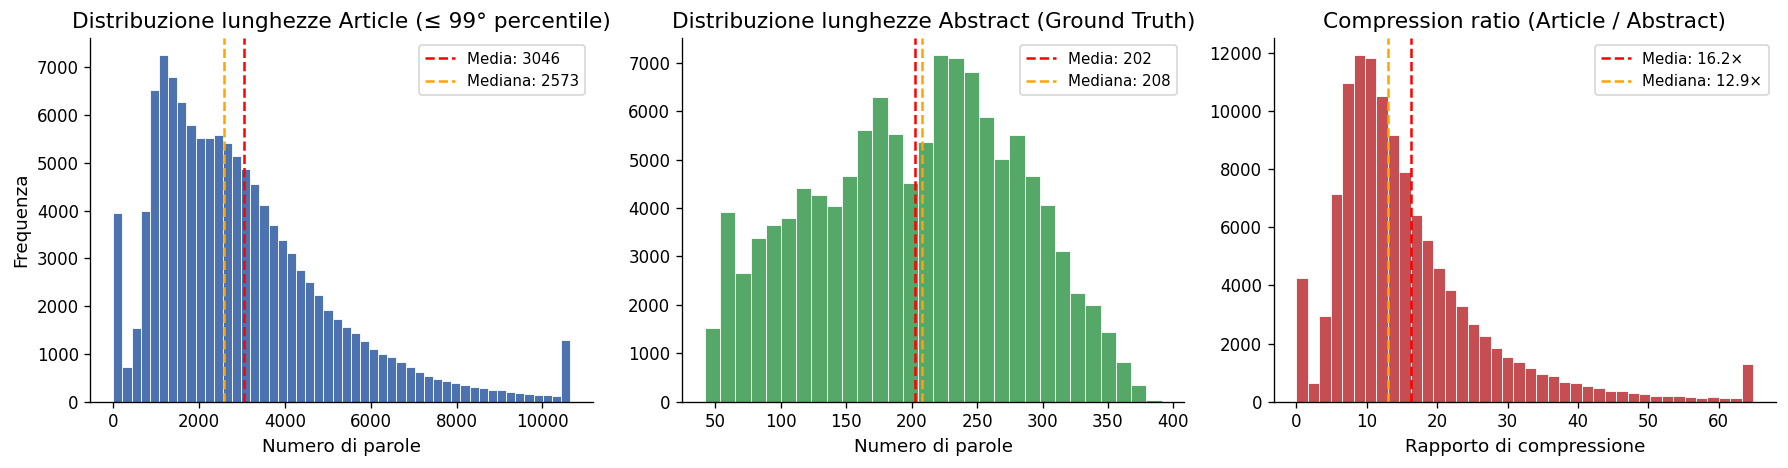

Figura salvata in results/fig_length_distributions_pubmed.png


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Article (clip per evitare valori estremi che schiacciano il grafico)
max_words = df['article_words'].quantile(0.99)  # 99° percentile
axes[0].hist(df['article_words'].clip(upper=max_words), bins=50, color='#4C72B0', edgecolor='white', linewidth=0.5)
axes[0].axvline(df['article_words'].mean(),  color='red',    linestyle='--', linewidth=1.5, label=f'Media: {df["article_words"].mean():.0f}')
axes[0].axvline(df['article_words'].median(), color='orange', linestyle='--', linewidth=1.5, label=f'Mediana: {df["article_words"].median():.0f}')
axes[0].set_title('Distribuzione lunghezze Article (≤ 99° percentile)')
axes[0].set_xlabel('Numero di parole')
axes[0].set_ylabel('Frequenza')
axes[0].legend(fontsize=9)

# Abstract
axes[1].hist(df['abstract_words'], bins=30, color='#55A868', edgecolor='white', linewidth=0.5)
axes[1].axvline(df['abstract_words'].mean(),  color='red',    linestyle='--', linewidth=1.5, label=f'Media: {df["abstract_words"].mean():.0f}')
axes[1].axvline(df['abstract_words'].median(), color='orange', linestyle='--', linewidth=1.5, label=f'Mediana: {df["abstract_words"].median():.0f}')
axes[1].set_title('Distribuzione lunghezze Abstract (Ground Truth)')
axes[1].set_xlabel('Numero di parole')
axes[1].legend(fontsize=9)

# Compression ratio (clip per valori estremi)
max_ratio = df['compression_ratio'].quantile(0.99)
axes[2].hist(df['compression_ratio'].clip(upper=max_ratio), bins=40, color='#C44E52', edgecolor='white', linewidth=0.5)
axes[2].axvline(df['compression_ratio'].mean(),  color='red',    linestyle='--', linewidth=1.5, label=f'Media: {df["compression_ratio"].mean():.1f}×')
axes[2].axvline(df['compression_ratio'].median(), color='orange', linestyle='--', linewidth=1.5, label=f'Mediana: {df["compression_ratio"].median():.1f}×')
axes[2].set_title('Compression ratio (Article / Abstract)')
axes[2].set_xlabel('Rapporto di compressione')
axes[2].legend(fontsize=9)

plt.tight_layout()

os.makedirs('results', exist_ok=True)
plt.savefig('results/fig_length_distributions_pubmed.png', bbox_inches='tight')
plt.show()
print('Figura salvata in results/fig_length_distributions_pubmed.png')

## 5. Scatter: Lunghezza CHQ vs Summary

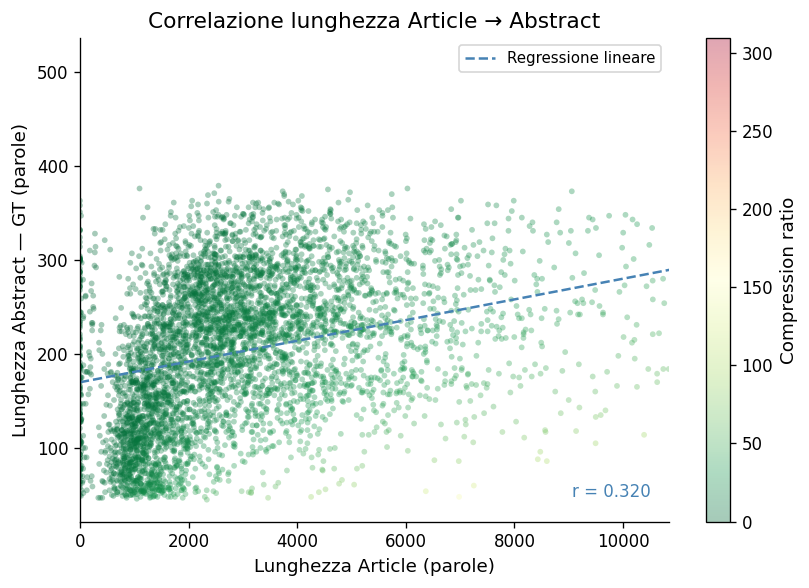

In [17]:
fig, ax = plt.subplots(figsize=(7, 5))

# Campiona per non appesantire il grafico (se dataset grande)
sample = df.sample(min(5000, len(df)), random_state=42)

sc = ax.scatter(
    sample['article_words'], sample['abstract_words'],
    alpha=0.35, s=12, c=sample['compression_ratio'],
    cmap='RdYlGn_r', edgecolors='none'
)
plt.colorbar(sc, ax=ax, label='Compression ratio')

# Linea di regressione
m, b = np.polyfit(sample['article_words'], sample['abstract_words'], 1)
x_line = np.linspace(sample['article_words'].min(), sample['article_words'].max(), 100)
ax.plot(x_line, m * x_line + b, color='steelblue', linewidth=1.5, linestyle='--', label='Regressione lineare')

ax.set_xlabel('Lunghezza Article (parole)')
ax.set_ylabel('Lunghezza Abstract — GT (parole)')
ax.set_title('Correlazione lunghezza Article → Abstract')
ax.legend(fontsize=9)
ax.set_xlim(0, sample['article_words'].quantile(0.99))  # zoom per evitare outlier estremi

corr = sample['article_words'].corr(sample['abstract_words'])
ax.text(0.97, 0.05, f'r = {corr:.3f}', transform=ax.transAxes,
        ha='right', fontsize=10, color='steelblue')

plt.tight_layout()
plt.savefig('results/fig_scatter_article_vs_abstract.png', bbox_inches='tight')
plt.show()

## 6. Casi Estremi: CHQ molto lunghi e molto corti

In [18]:
print('=== TOP 3 Article più lunghi ===')
long_df = df.nlargest(3, 'article_words')[['article_words', 'article', 'abstract']]
for _, row in long_df.iterrows():
    print(f'\n[{row["article_words"]} parole]')
    print(f'  Article:  {row["article"][:300]}...')
    print(f'  Abstract: {row["abstract"]}')

print('\n=== TOP 3 Article più corti ===')
short_df = df.nsmallest(3, 'article_words')[['article_words', 'article', 'abstract']]
for _, row in short_df.iterrows():
    print(f'\n[{row["article_words"]} parole]')
    print(f'  Article:  {row["article"][:300]}...')
    print(f'  Abstract: {row["abstract"]}')

=== TOP 3 Article più lunghi ===

[109759 parole]
  Article:  the search for a physically viable theory of quantized gravitation is ongoing ; in part because the physics it ought to describe is unknown , and in part because different approaches may not 
 the most prominent contenders are string theory and loop quantum gravity , with ample literature available ...
  Abstract: the asymptotic safety scenario in quantum gravity is reviewed , according to which a renormalizable quantum theory of the gravitational field is feasible which reconciles asymptotically safe couplings with unitarity . 
 the evidence from symmetry truncations and from the truncated flow of the effective average action is presented in detail . a dimensional reduction phenomenon for the residual interactions in the extreme ultraviolet links both results . for practical reasons 
 the background effective action is used as the central object in the quantum theory . in terms of it 
 criteria for a continuum limit are for

## 7. Fasce di Complessità

                n_esempi  media_article_words  media_abstract_words  media_ratio
article_bucket                                                                  
≤500                2187               215.24                159.58         1.93
501–1000            9588               812.89                122.45         7.92
1001–2000          30485              1473.91                163.52        11.15
2001–5000          57146              3244.82                228.87        15.89
>5000              17641              7165.66                234.36        34.84


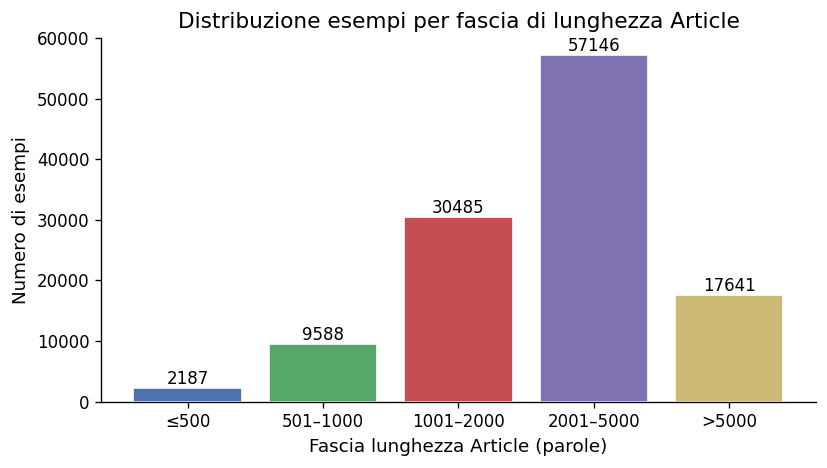

In [19]:
# PubMed ha articoli molto più lunghi → fasce diverse
bins   = [0, 500, 1000, 2000, 5000, float('inf')]
labels = ['≤500', '501–1000', '1001–2000', '2001–5000', '>5000']

df['article_bucket'] = pd.cut(df['article_words'], bins=bins, labels=labels)

bucket_stats = df.groupby('article_bucket', observed=True).agg(
    n_esempi           = ('article', 'count'),
    media_article_words = ('article_words', 'mean'),
    media_abstract_words = ('abstract_words', 'mean'),
    media_ratio        = ('compression_ratio', 'mean'),
).round(2)

print(bucket_stats.to_string())

# Bar chart
fig, ax = plt.subplots(figsize=(7, 4))
colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2', '#CCB974']
bars = ax.bar(bucket_stats.index, bucket_stats['n_esempi'], color=colors, edgecolor='white')

for bar, val in zip(bars, bucket_stats['n_esempi']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
            str(val), ha='center', va='bottom', fontsize=10)

ax.set_xlabel('Fascia lunghezza Article (parole)')
ax.set_ylabel('Numero di esempi')
ax.set_title('Distribuzione esempi per fascia di lunghezza Article')
plt.tight_layout()
plt.savefig('results/fig_article_buckets_pubmed.png', bbox_inches='tight')
plt.show()

## 8. Riepilogo Finale

In [20]:
print('╔══════════════════════════════════════════════════════════════╗')
print('║     RIEPILOGO DATASET PubMed Summarization                   ║')
print('╠══════════════════════════════════════════════════════════════╣')
print(f'║  Totale esempi          : {len(df):>6}                               ║')
print(f'║  Valori nulli           : {df[["article","abstract"]].isnull().sum().sum():>6}                               ║')
print(f'║  Duplicati              : {df.duplicated().sum():>6}                               ║')
print(f'║  Article — media parole : {df["article_words"].mean():>6.1f}                               ║')
print(f'║  Article — max parole   : {df["article_words"].max():>6}                               ║')
print(f'║  Abstract — media parole: {df["abstract_words"].mean():>6.1f}                               ║')
print(f'║  Compression ratio medio: {df["compression_ratio"].mean():>6.1f}×                              ║')
print('╚══════════════════════════════════════════════════════════════╝')



╔══════════════════════════════════════════════════════════════╗
║     RIEPILOGO DATASET PubMed Summarization                   ║
╠══════════════════════════════════════════════════════════════╣
║  Totale esempi          : 119850                               ║
║  Valori nulli           :      0                               ║


║  Duplicati              :      0                               ║
║  Article — media parole : 3045.8                               ║
║  Article — max parole   : 109759                               ║
║  Abstract — media parole:  202.2                               ║
║  Compression ratio medio:   16.2×                              ║
╚══════════════════════════════════════════════════════════════╝


Implicazioni per le pipeline:
  • TextRank (Pipeline A): compression ratio > 20× → selezionare 5-10 frasi (non 1-2)
  • TextRank (Pipeline A): articoli lunghi → ottimizzare la matrice di similarità (soglia di similarità)
  • LLM (Pipeline B): articoli lunghi (3000-6000 parole, ~4000-8000 token) → usare modello con context window ≥ 32k (Mixtral 8x7B)
  • LLM (Pipeline B): abstract lunghi (~200 parole) → max_new_tokens = 256-512
  • NER: gli abstract contengono molte entità mediche (farmaci, malattie, sintomi)

In [21]:
# Salva dataset con feature e pulito per l'uso nel main
df.to_csv('../data/pubmed_cleaned.csv', index=False)
print(f'\n✅ Dataset pulito salvato in data/pubmed_cleaned.csv ({len(df)} esempi)')
print(f'   Colonne disponibili: {list(df.columns)}')


✅ Dataset pulito salvato in data/pubmed_cleaned.csv (119850 esempi)
   Colonne disponibili: ['article', 'abstract', 'article_words', 'article_chars', 'abstract_words', 'abstract_chars', 'compression_ratio', 'article_bucket']
